# 23CSE301 Machine Learning — Capstone Project
## Review 1: Dataset & EDA, Preprocessing, Regression Track, Classification Part A

**Dataset:** `Sales_transactions_2022_2025.csv`

### Problem statements used in this notebook

- **Regression target:** `Profit` — predict transaction profit from information known at transaction time.
- **Classification target:** `Return_Flag` — predict whether a transaction will be returned (`No` / `Yes`).

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing / model selection
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Libraries loaded.")

Libraries loaded.


## Section A — Dataset Loading & Audit (A1)

Load the Sales Transactions dataset and inspect its structure, missing values, duplicates, target statistics, and target distribution.

In [2]:
DATA_PATH = "Sales_transactions_2022_2025.csv"  # Keep the CSV in the same folder as this notebook.
df_raw = pd.read_csv(DATA_PATH)

print("Shape (rows, columns):", df_raw.shape)
print("\nData types:")
print(df_raw.dtypes)

Shape (rows, columns): (18045, 36)

Data types:
Transaction_ID              str
Order_ID                    str
Customer_ID                 str
Customer_Name               str
Customer_Age            float64
Customer_Gender             str
Customer_Segment            str
Order_Date                  str
Order_Time                  str
Sales_Channel               str
Store_ID                    str
Store_Name                  str
Country                     str
Region                      str
City                        str
Product_ID                  str
Product_Name                str
Product_Category            str
Product_Subcategory         str
Quantity                  int64
Unit_Price              float64
Discount_Percentage     float64
Sales_Amount            float64
Cost_Amount             float64
Profit                  float64
Payment_Method              str
Order_Status                str
Shipping_Method             str
Delivery_Days           float64
Return_Flag             

In [3]:
print("Missing values per column:")
print(df_raw.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df_raw.duplicated().sum())

print("\nRegression target (`Profit`) summary:")
print(df_raw["Profit"].describe())

print("\nClassification target (`Return_Flag`) distribution:")
print(df_raw["Return_Flag"].value_counts())
print(df_raw["Return_Flag"].value_counts(normalize=True).round(3))

Missing values per column:
Return_Reason           16168
Promotion_Code           9737
Customer_Rating          3435
Customer_Age              218
Inventory_Level           198
Customer_Gender           162
Delivery_Days             162
Payment_Method            147
Product_Name              144
Customer_Name             108
Transaction_ID              0
Order_ID                    0
Customer_ID                 0
Country                     0
Store_Name                  0
Customer_Segment            0
Order_Time                  0
Sales_Channel               0
Store_ID                    0
Order_Date                  0
Quantity                    0
Product_Subcategory         0
Product_Category            0
Product_ID                  0
Region                      0
City                        0
Sales_Amount                0
Unit_Price                  0
Shipping_Method             0
Order_Status                0
Profit                      0
Cost_Amount                 0
Discount_Perc

In [4]:
# Compact numerical audit
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,18045,18000,T02009714,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_ID,18045,14541,O0102892,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,18045,4882,C02559,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,17937,1179,Amelia King,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,17827.0,NaN,NaN,NaN,38.916924,10.727357,4.0,32.0,39.0,46.0,112.0
Customer_Gender,17883,6,Female,8742,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Segment,18045,6,Consumer,8039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,18045,1461,2024-12-25,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,18045,15201,12:29:48,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_Channel,18045,4,Online,8211,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset suitability check

The dataset supports both regression and classification because it contains a continuous target (`Profit`), a binary target (`Return_Flag`), numerical and categorical predictors, and transaction, customer, product, geographical, and temporal information.

**Viva note:** The classification target is imbalanced, so stratification and weighted metrics are used.

## Section A — Exploratory Data Analysis (A2, A3)

Explore feature distributions, correlations, target distribution, and relationships between important features and `Profit`.

In [5]:
df_eda = df_raw.copy()

df_eda["Order_Date"] = pd.to_datetime(df_eda["Order_Date"], errors="coerce")
df_eda["Order_Time"] = pd.to_datetime(df_eda["Order_Time"], format="%H:%M:%S", errors="coerce")

print("EDA copy created.")

EDA copy created.


Numerical features: 11
Categorical/date-time features: 25


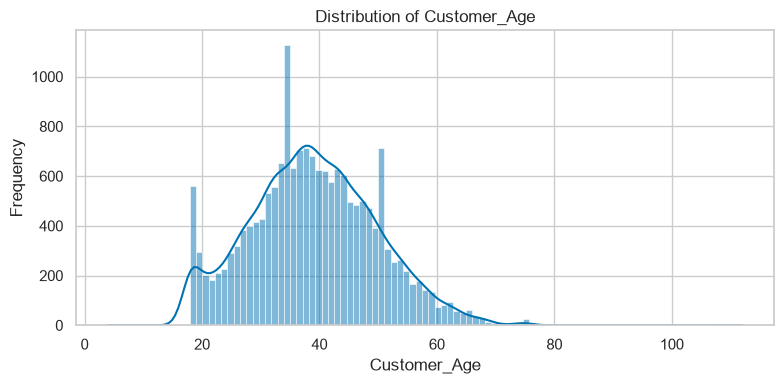

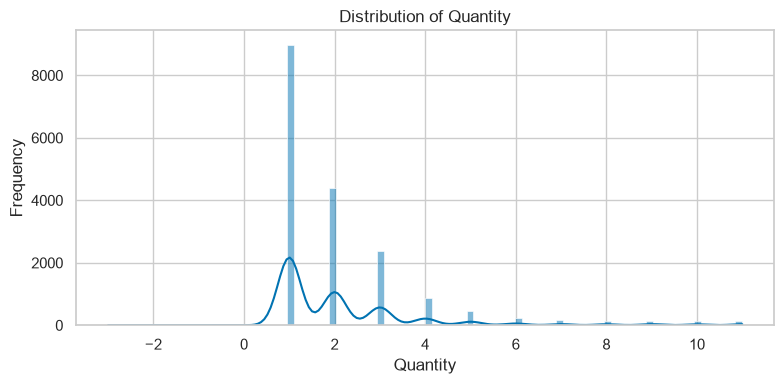

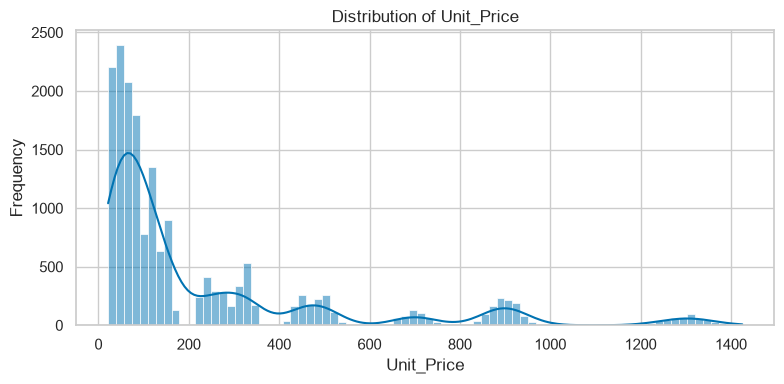

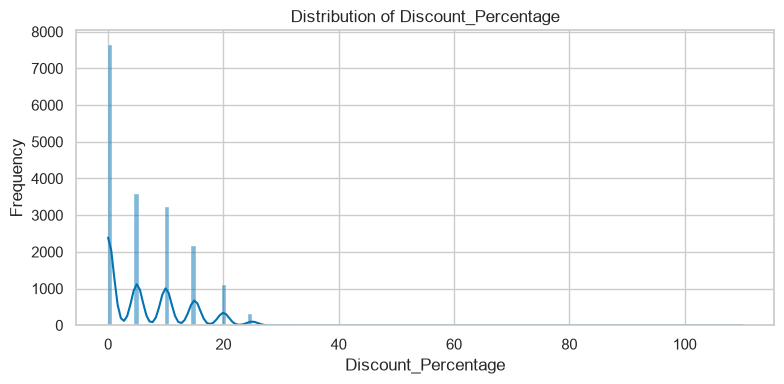

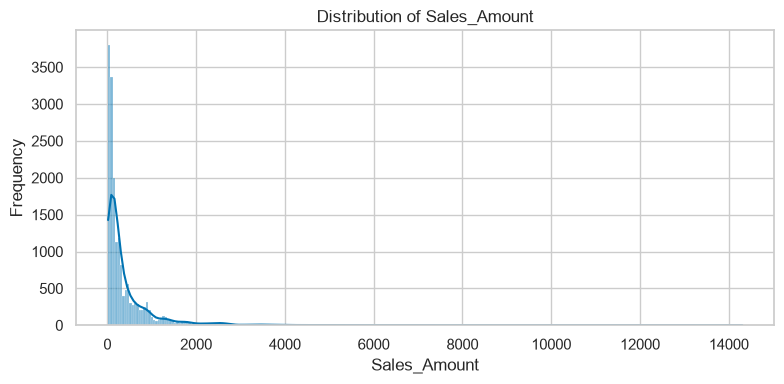

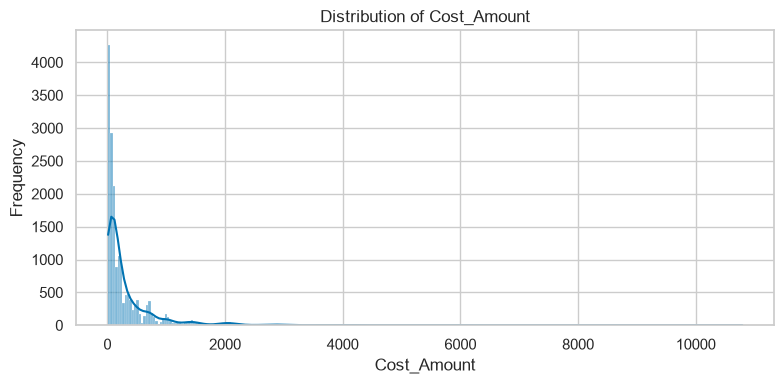

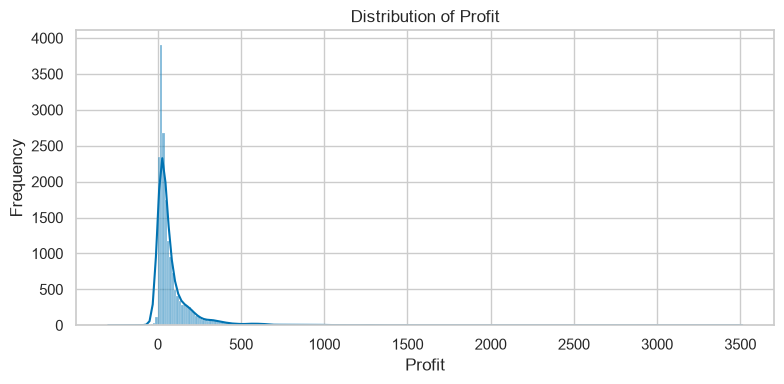

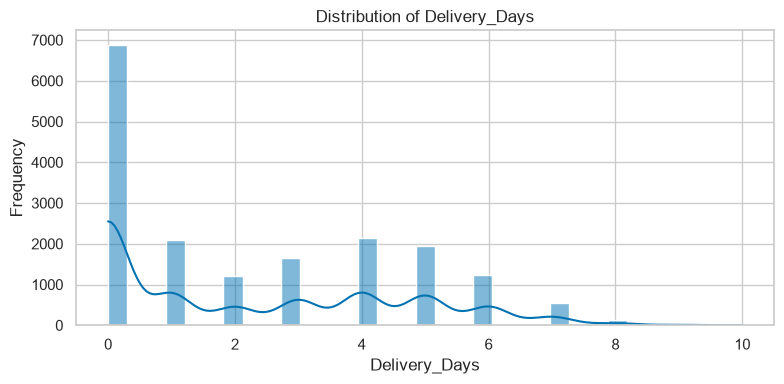

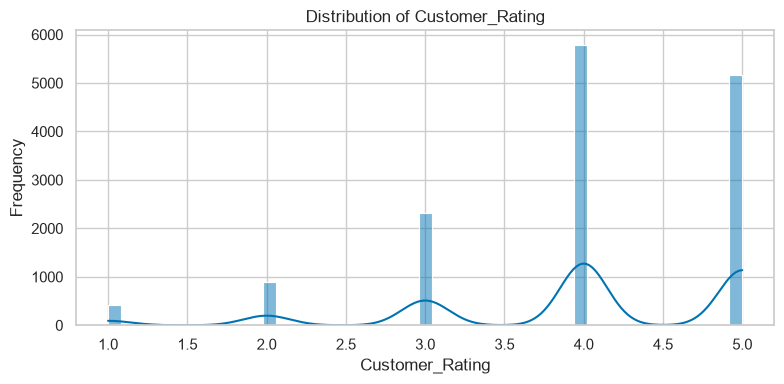

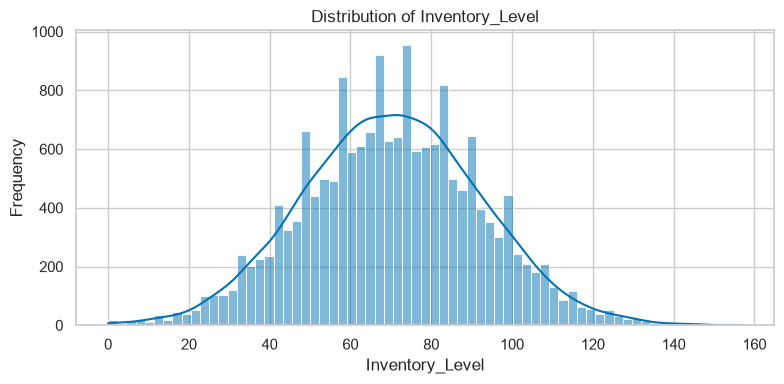

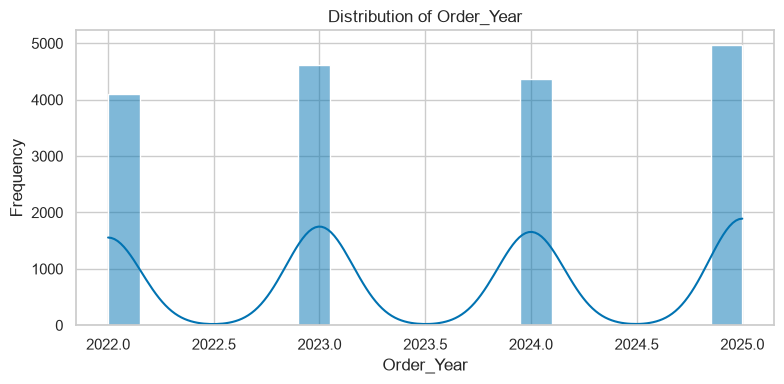

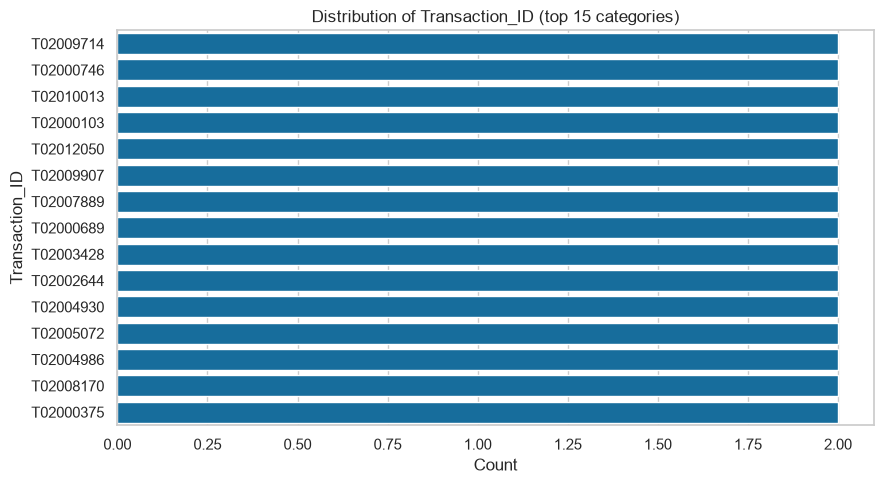

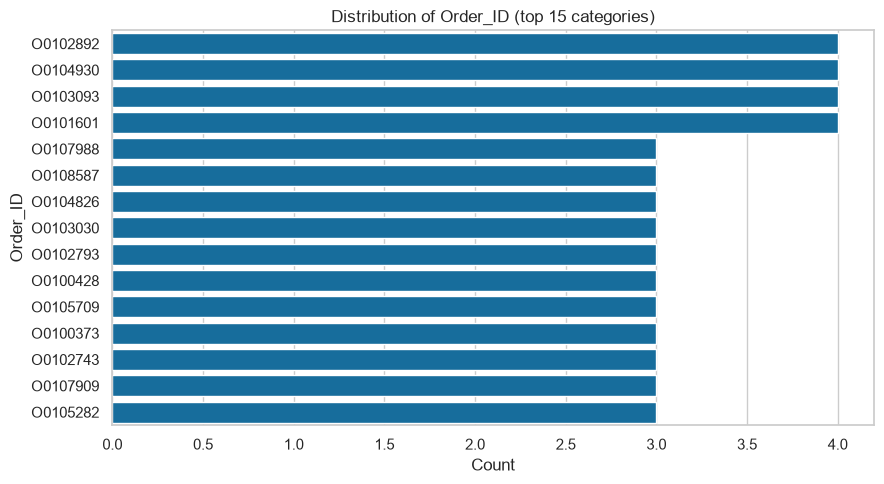

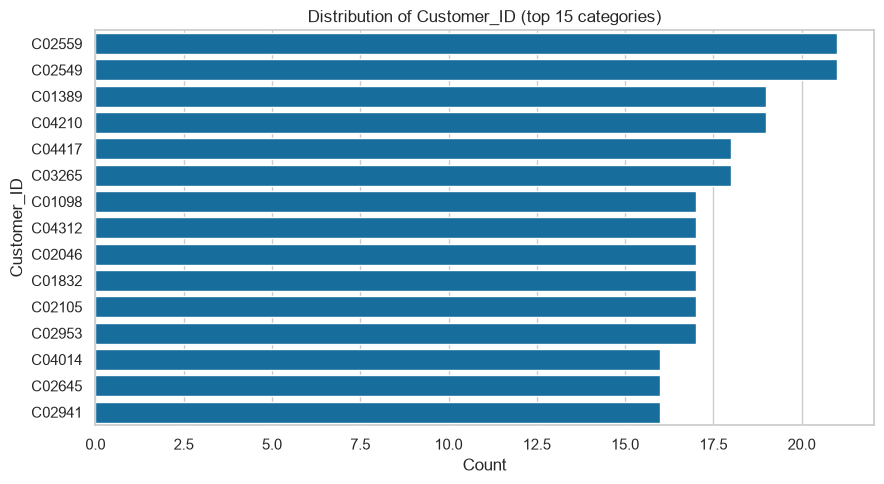

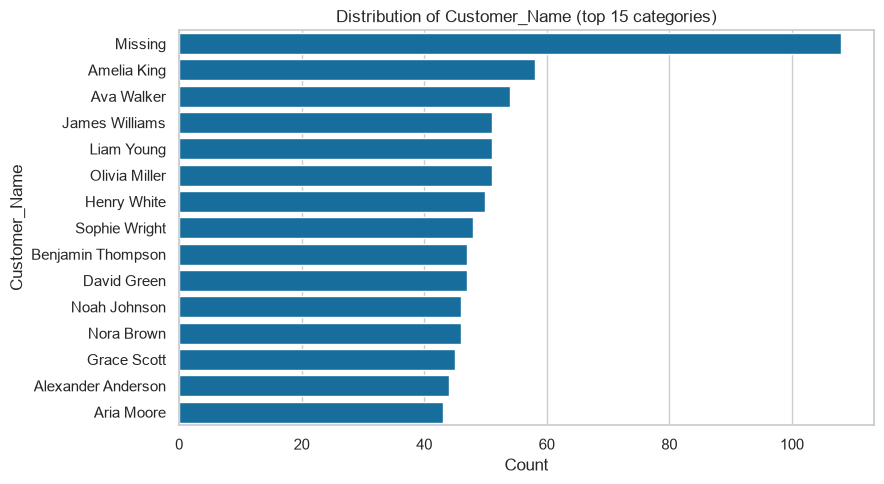

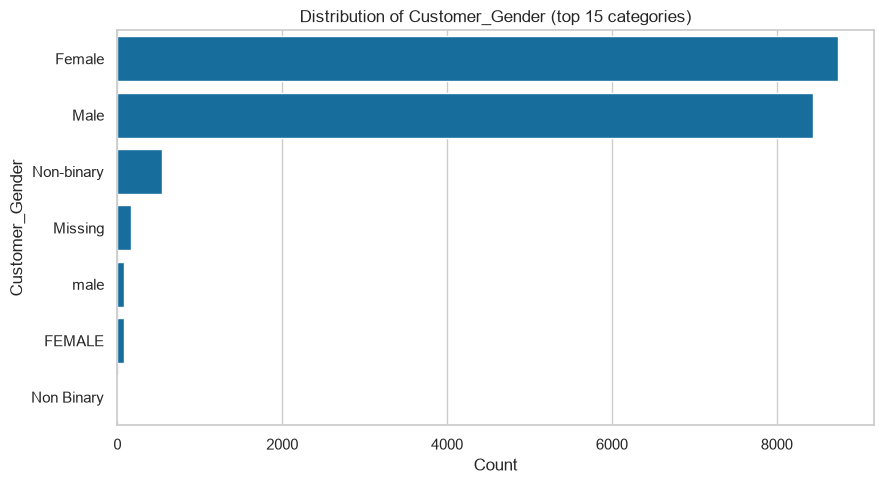

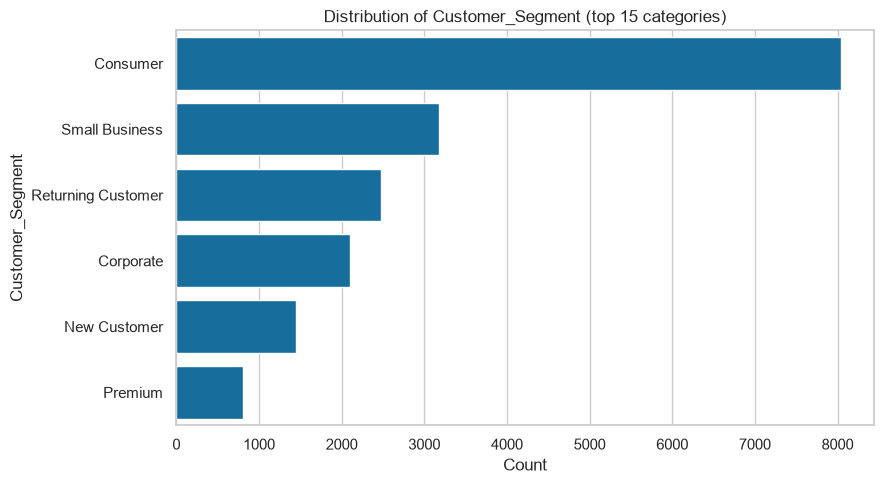

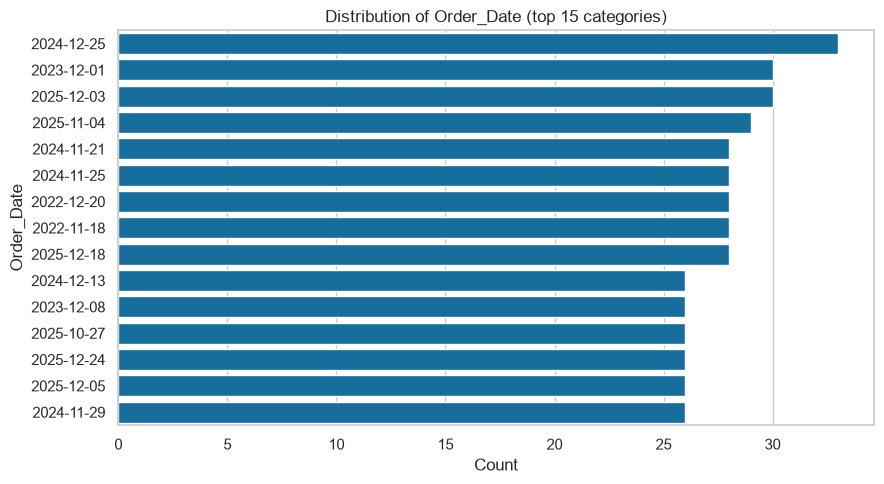

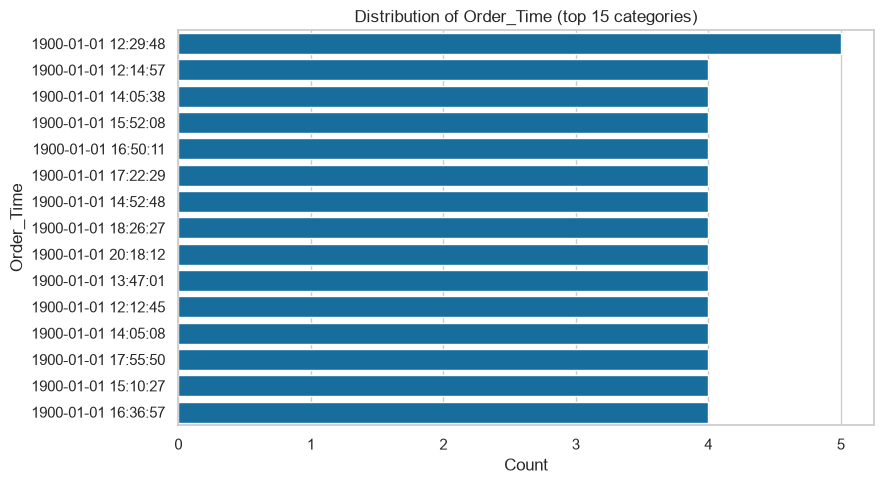

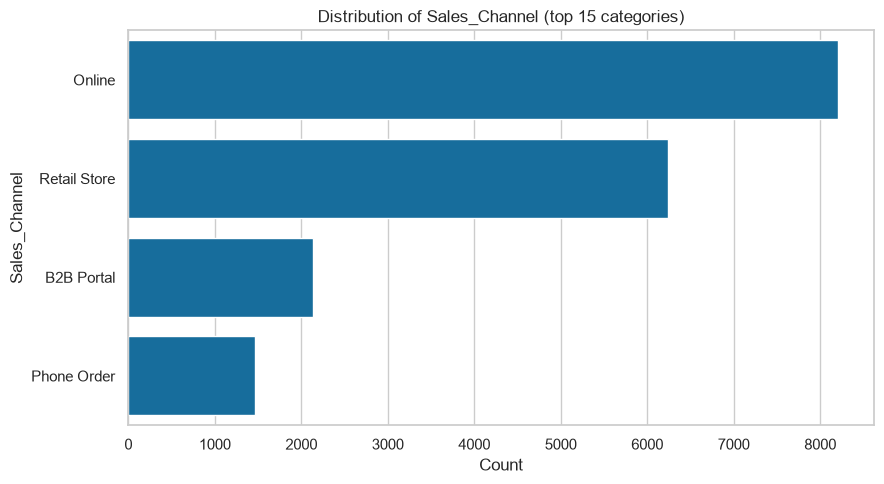

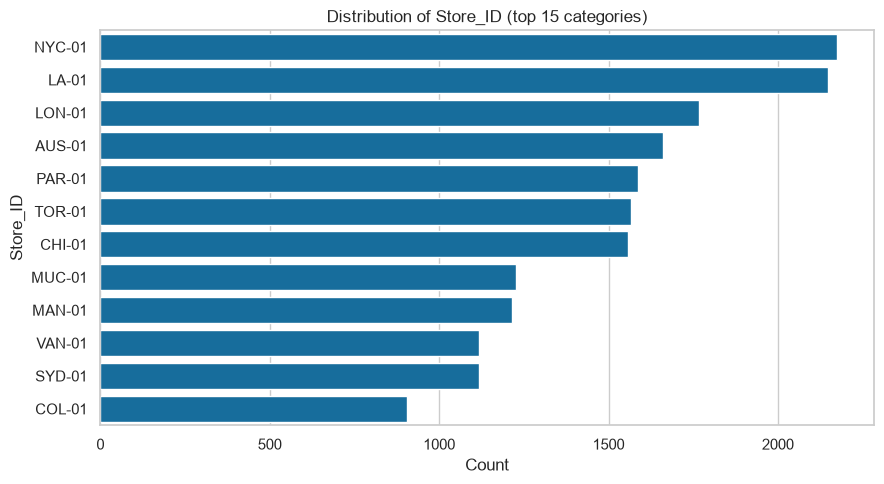

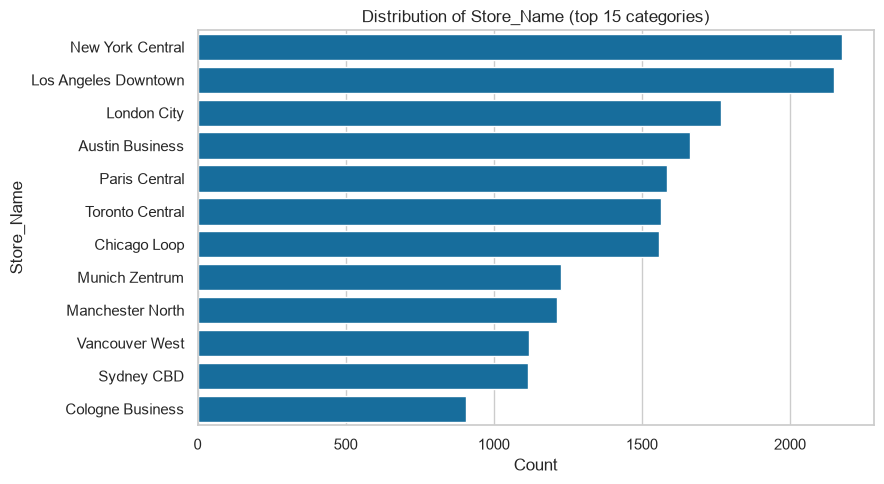

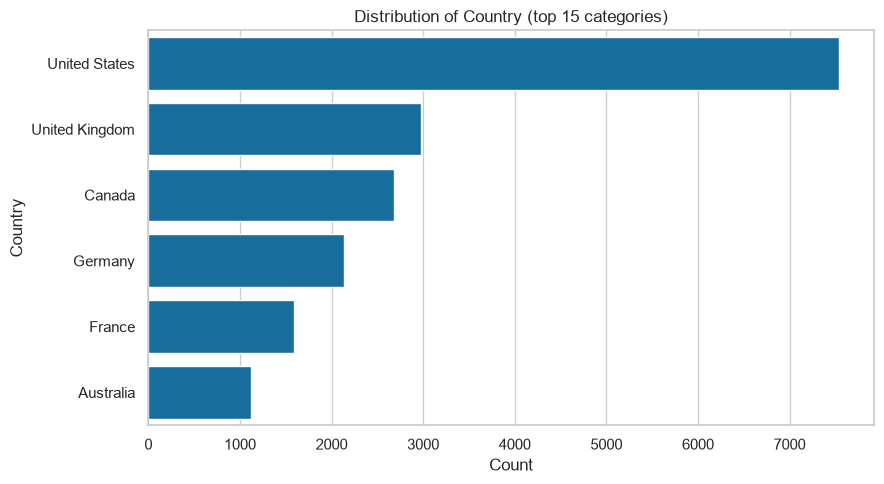

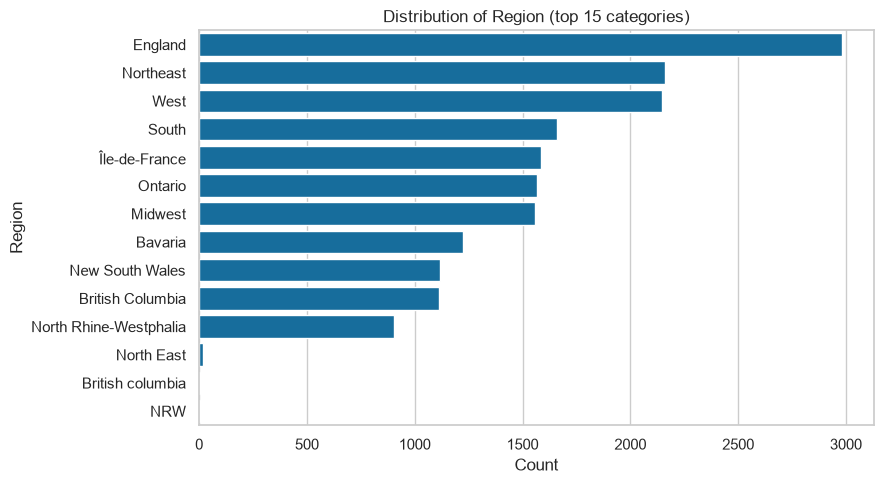

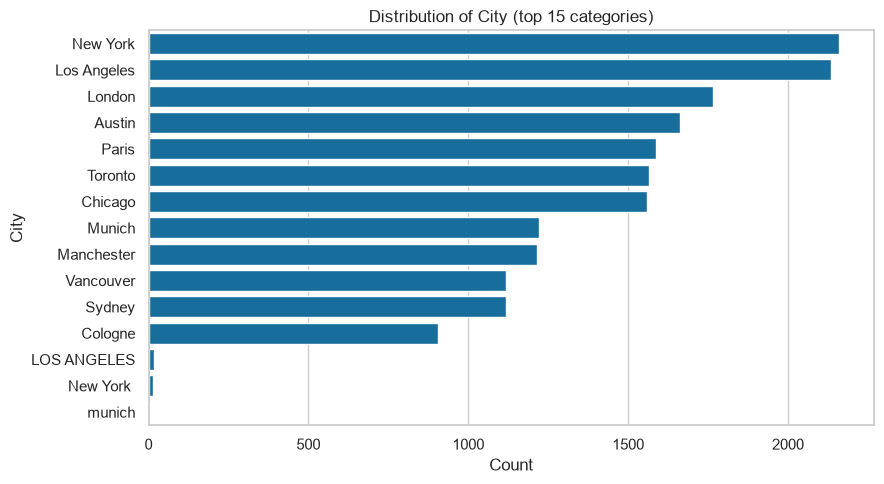

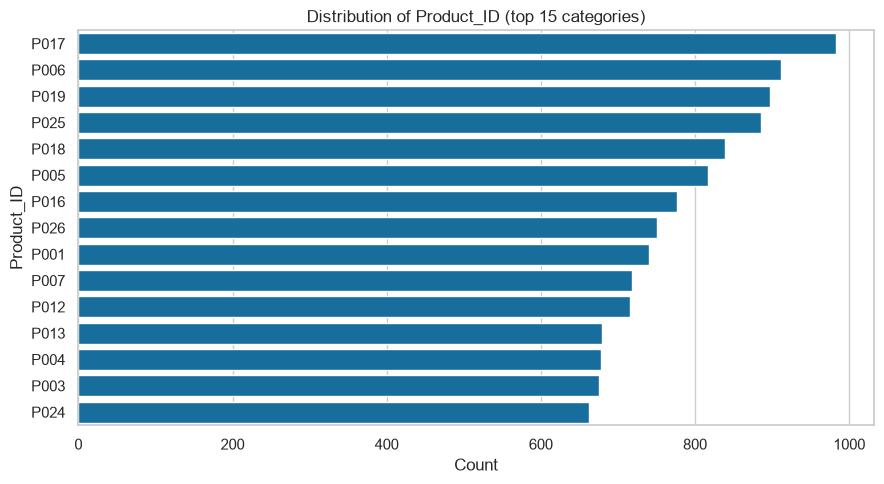

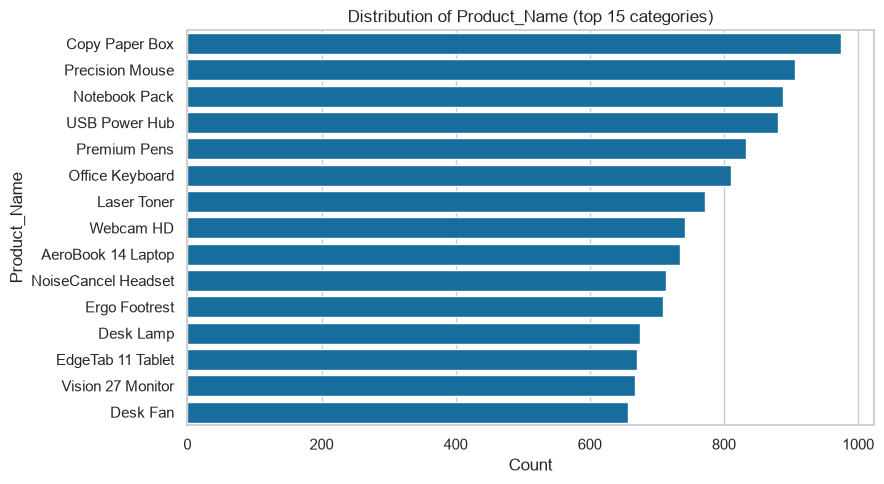

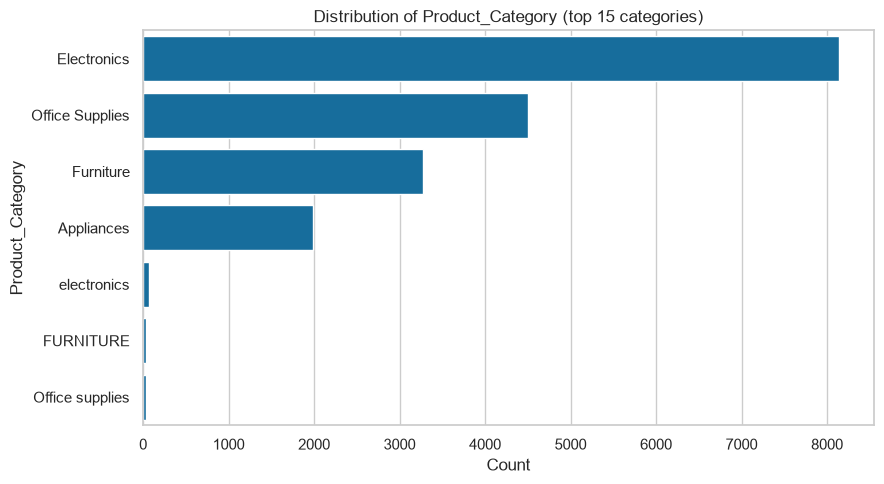

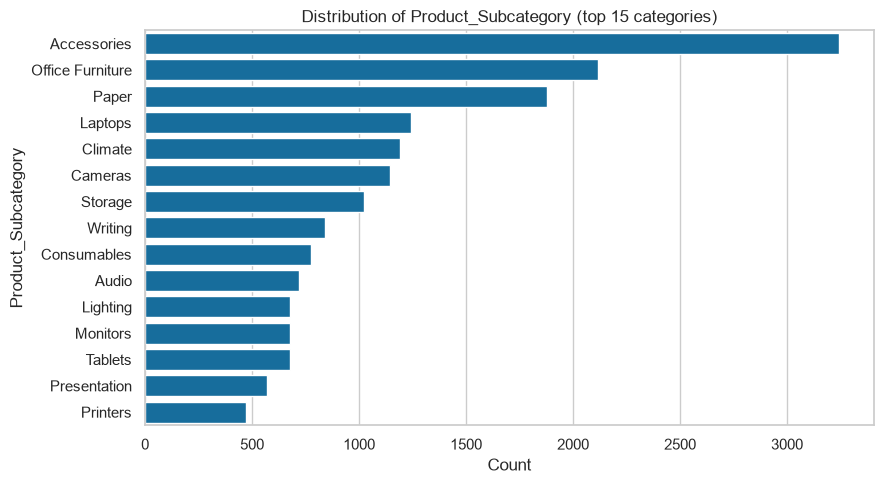

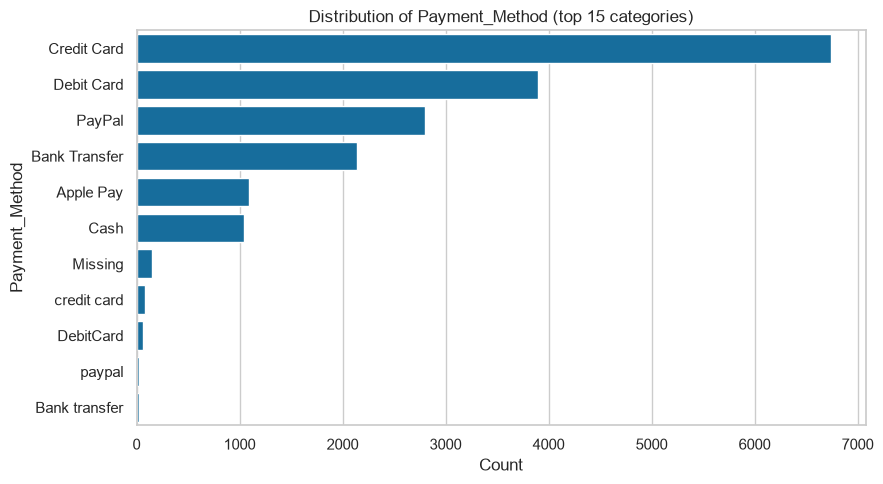

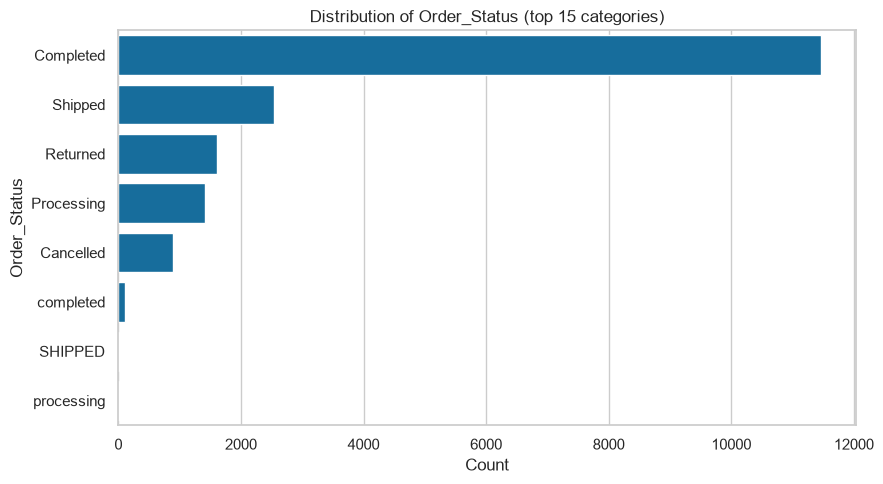

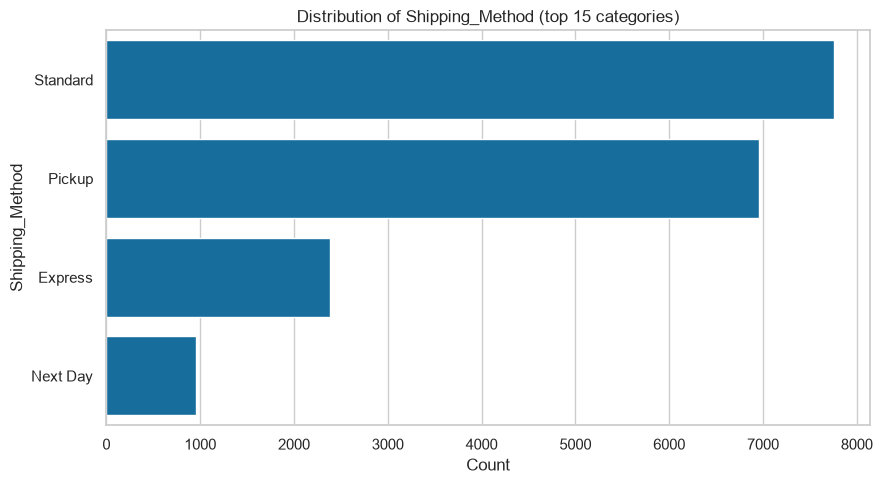

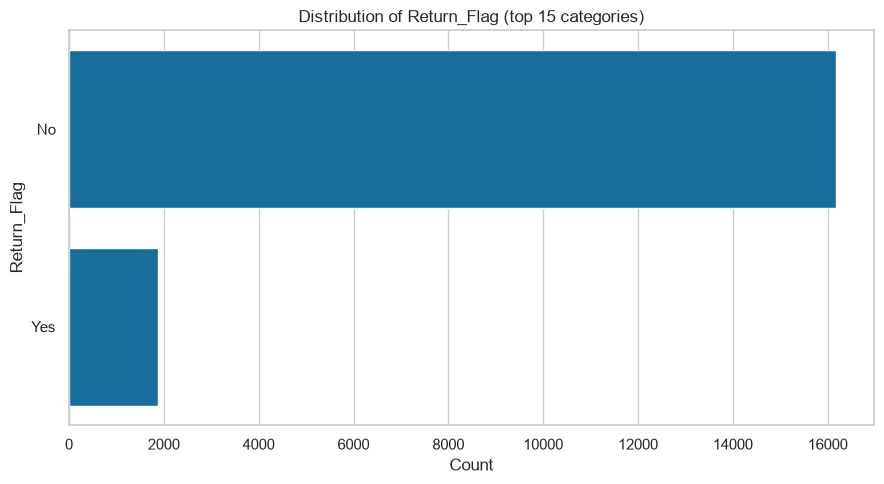

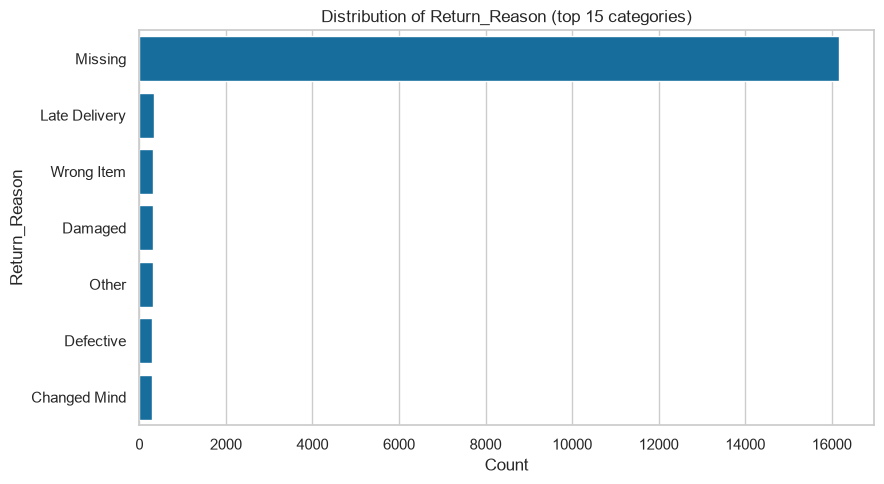

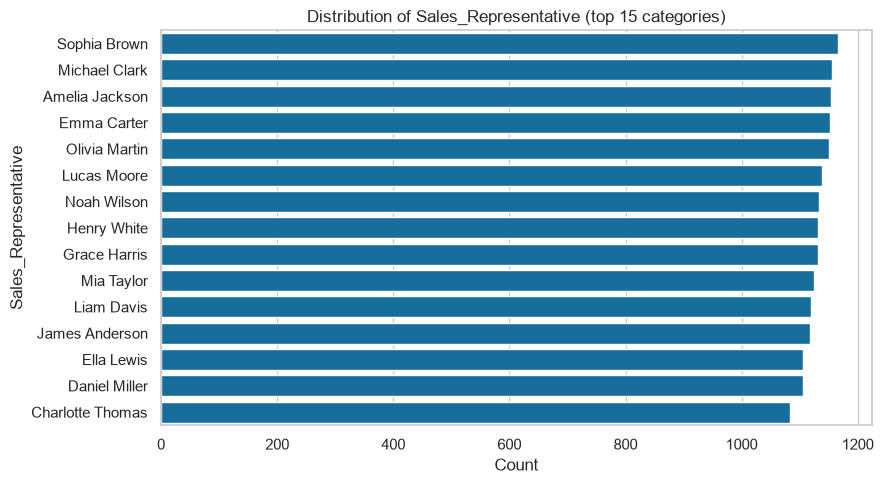

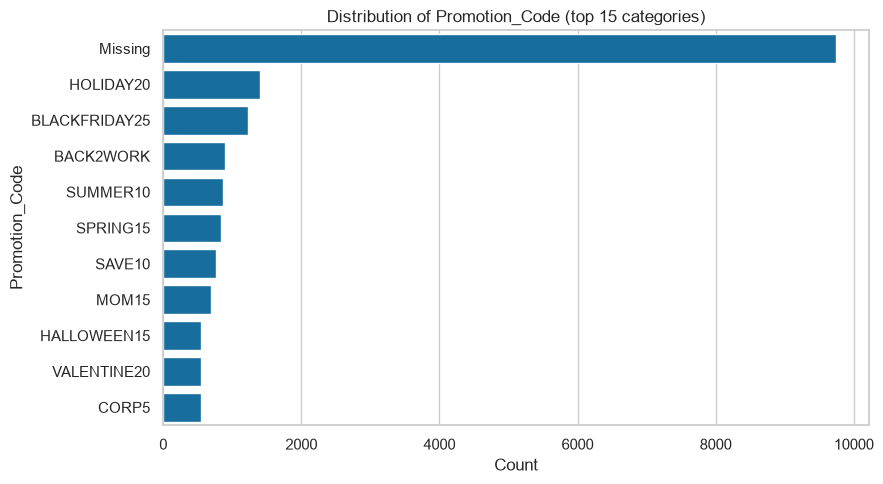

In [6]:
numeric_cols_eda = df_eda.select_dtypes(include=np.number).columns.tolist()
categorical_cols_eda = df_eda.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical features: {len(numeric_cols_eda)}")
print(f"Categorical/date-time features: {len(categorical_cols_eda)}")

for col in numeric_cols_eda:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_eda[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in categorical_cols_eda:
    plt.figure(figsize=(9, 5))
    counts = df_eda[col].astype("string").fillna("Missing").value_counts().head(15)
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(f"Distribution of {col} (top 15 categories)")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Observation — distributions:** The numerical features show several distinct patterns. `Customer_Age` is roughly bell-shaped and concentrated around the late-30s/40s, with a few extreme ages. `Quantity` is discrete and concentrated at small values, mainly around 1–3, with some unusual negative and larger values. `Unit_Price`, `Sales_Amount`, `Cost_Amount`, and `Profit` are strongly right-skewed, with most observations at relatively low values and a smaller number of very large transactions. `Discount_Percentage` is concentrated at low discount levels but contains a few extreme values, including values above 100%. `Delivery_Days` is discrete and concentrated at low values, while `Customer_Rating` is heavily concentrated at 4–5. `Inventory_Level` is approximately bell-shaped around the middle of its range, and `Order_Year` covers 2022–2025. The categorical plots show clear dominant categories—for example, `Female` for gender, `Consumer` for customer segment, `Online` for sales channel, `Electronics` for product category, and `Credit Card` for payment method—along with less frequent categories. Some categorical fields also contain inconsistent capitalization/spelling, supporting the later standardisation step. Missing values are visible as an important issue in fields such as `Return_Reason` and `Promotion_Code`, so the modelling pipelines need explicit missing-value handling.

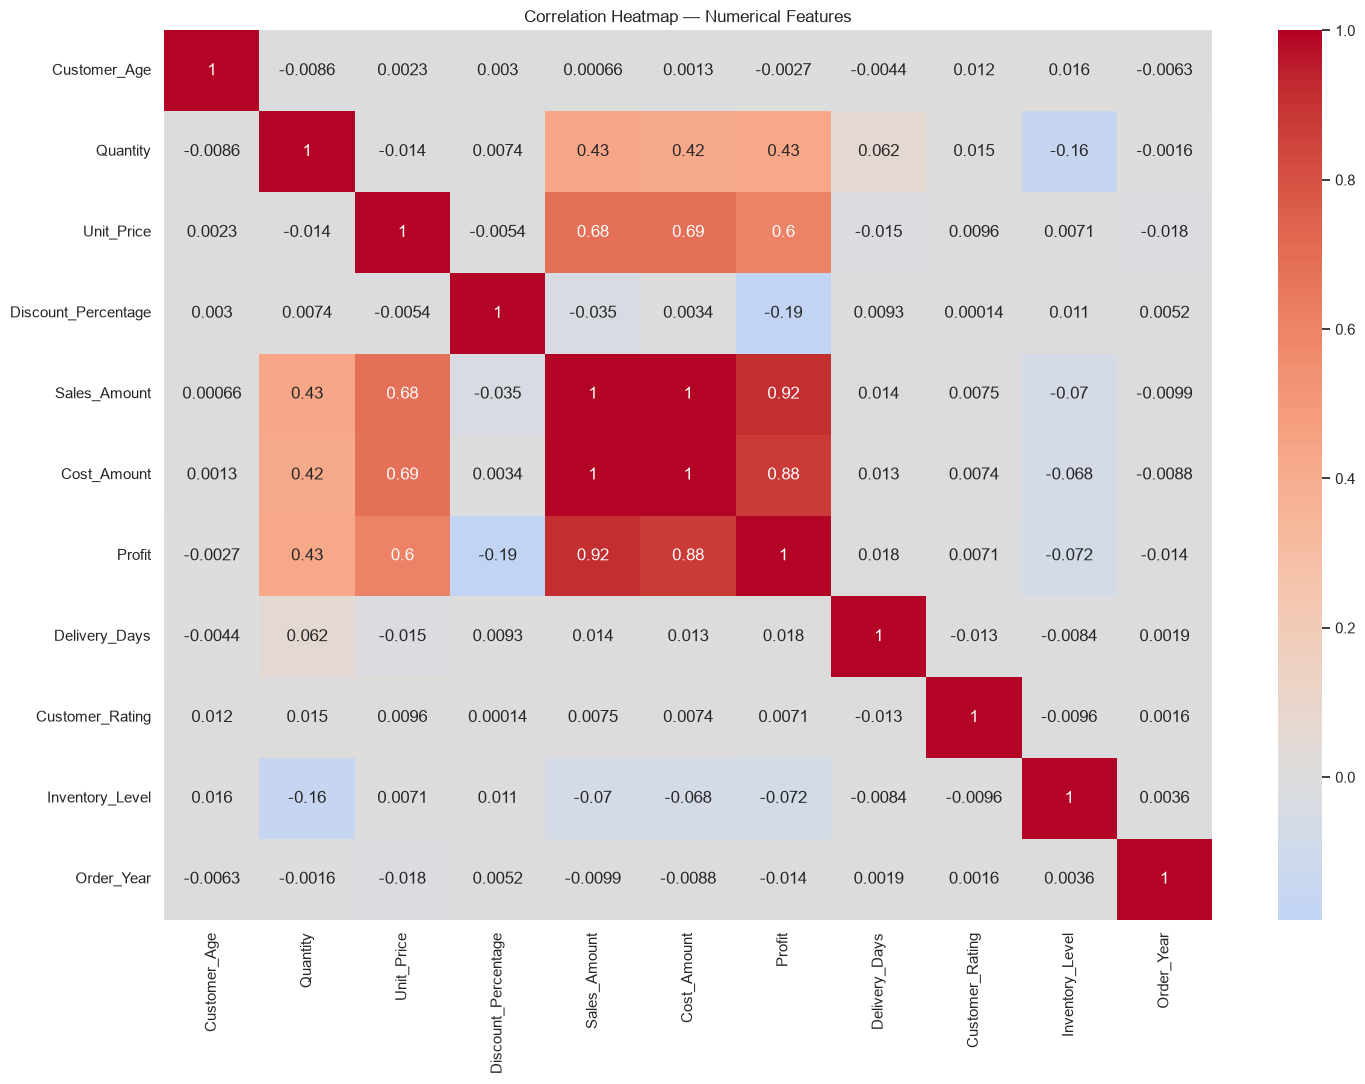

In [7]:
# Correlation heatmap for numerical variables.
plt.figure(figsize=(15, 11))
corr = df_eda.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

**Observation — correlation heatmap:** `Profit` has a very strong positive correlation with `Sales_Amount` (about 0.92) and a strong positive correlation with `Cost_Amount` (about 0.88). It also has a moderate positive correlation with `Unit_Price` (about 0.60) and `Quantity` (about 0.43), while `Discount_Percentage` has a modest negative correlation with `Profit` (about -0.19). `Sales_Amount` and `Cost_Amount` are almost perfectly correlated (about 1.00), indicating substantial redundancy between them. Most of the remaining numerical predictors have weak correlations with `Profit`. The very strong relationships involving `Sales_Amount` and `Cost_Amount` also explain why these variables are excluded from the regression predictors: they are directly tied to the target and would create leakage rather than a realistic prediction setup.

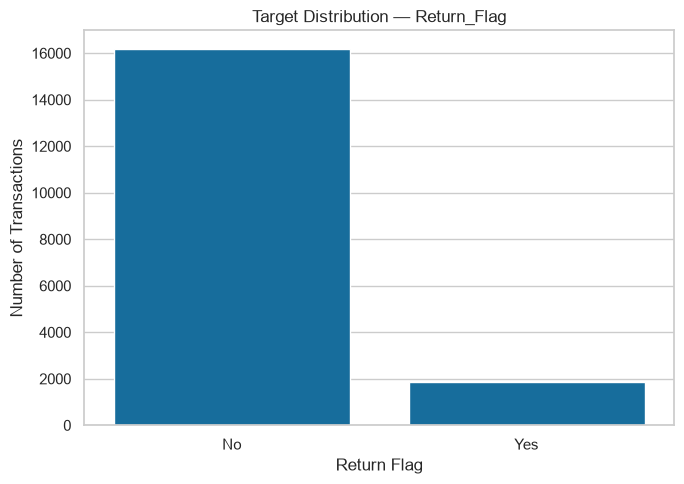

In [8]:
# Classification target distribution
plt.figure(figsize=(7, 5))
counts = df_eda["Return_Flag"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.title("Target Distribution — Return_Flag")
plt.xlabel("Return Flag")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

**Observation — target distribution:** `Return_Flag` is clearly imbalanced. There are 16,168 `No` transactions (about 89.6%) and 1,877 `Yes` transactions (about 10.4%). Therefore, the `Yes`/return class is the minority class. A model that predicts `No` for almost every transaction can obtain high accuracy simply because `No` is much more common. For this reason, the classification split uses stratification so that the class proportions are preserved approximately in train and test sets, and the evaluation also reports weighted precision, recall and F1 together with the confusion matrix and ROC-AUC rather than relying on accuracy alone.

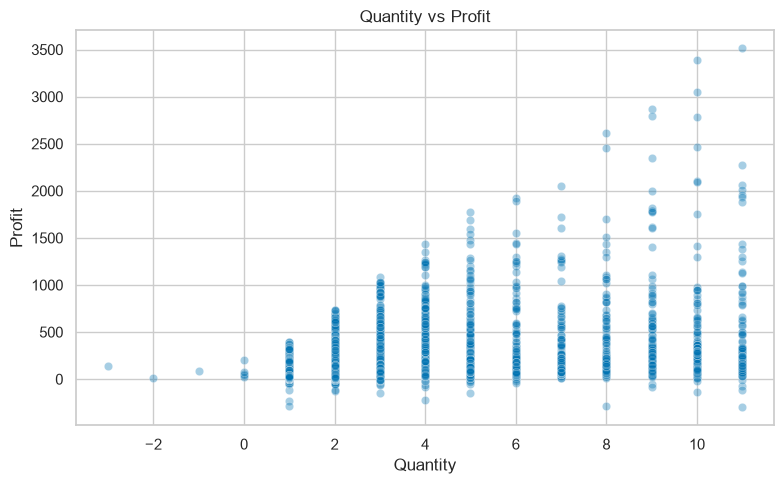

In [9]:
# Scatter plot 1: Quantity vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x="Quantity", y="Profit", alpha=0.35)
plt.title("Quantity vs Profit")
plt.xlabel("Quantity")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Observation — Quantity vs Profit:** The scatter plot shows a generally positive association between `Quantity` and `Profit`: higher quantities tend to be associated with higher possible profit values. However, the spread becomes quite wide as quantity increases, so the relationship is not perfectly linear or deterministic. Most observations are concentrated at lower quantities and lower-to-moderate profit values, while a smaller number of observations have much larger profits. There are also unusual observations, including negative quantities/profits and very high profit values. The plot indicates association only; it does not establish that quantity by itself causes profit to increase.

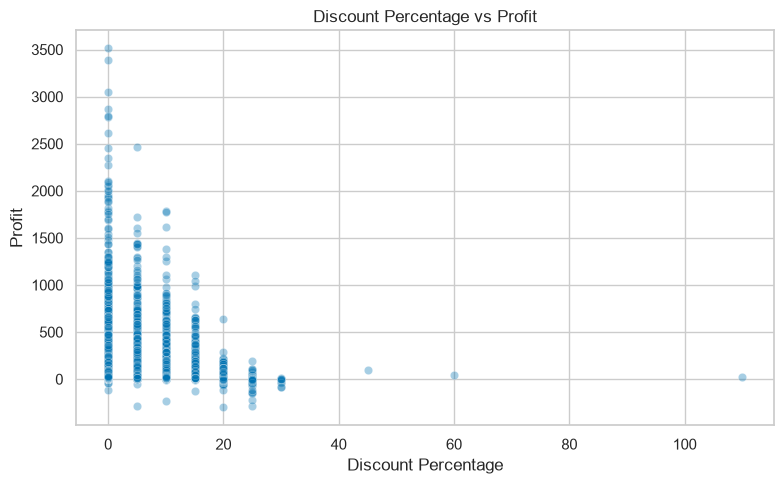

In [10]:
# Scatter plot 2: Discount Percentage vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda, x="Discount_Percentage", y="Profit", alpha=0.35)
plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

**Observation — Discount vs Profit:** The plot shows a generally negative association between `Discount_Percentage` and `Profit`. Transactions with low or zero discounts contain the widest range of profit values, including the highest profits, while higher discount levels are concentrated closer to zero and include some negative-profit observations. The pattern is not a tight straight-line relationship; there is substantial scatter, especially at lower discount levels. A few extreme discount values are also visible, including values well above the main range, which supports the need for outlier treatment during preprocessing.